We experiment by evaluating the performance of an optimised model (optimised on load feature stage using RMSE) using the saved best configurations on the load feature stage trained on MAE but evaluated using both MAE and RMSE.

In [1]:
import pandas as pd

training_start_date = '2020-01-01'

# Load data
train_df = pd.read_csv('~/data/Germany_time_zone/all/train_with_all.csv')
test_df = pd.read_csv('~/data/Germany_time_zone/all/test_with_all.csv')

# Filter train_df to include only data from 2020 onward
train_df = train_df[pd.to_datetime(train_df['ds']) >= pd.Timestamp(training_start_date)]

# Convert to UTC while handling DST ambiguities
train_df['ds'] = pd.to_datetime(train_df['ds']).dt.tz_localize('Europe/Berlin', ambiguous='infer').dt.tz_convert('UTC')
test_df['ds'] = pd.to_datetime(test_df['ds']).dt.tz_localize('Europe/Berlin', ambiguous='infer').dt.tz_convert('UTC')

# Check date ranges
print("First date in train_df:", train_df['ds'].min())
print("Last date in train_df:", train_df['ds'].max())
print("First date in test_df:", test_df['ds'].min())
print("Last date in test_df:", test_df['ds'].max())

First date in train_df: 2019-12-31 23:00:00+00:00
Last date in train_df: 2023-12-31 22:00:00+00:00
First date in test_df: 2023-12-31 23:00:00+00:00
Last date in test_df: 2024-12-31 22:00:00+00:00


In [2]:
train_df.head()

,ds,y,unique_id,day_of_week,month,hour,is_weekend,is_holiday,month_sin,month_cos,...,day_of_week_cos,hour_sin,hour_cos,gas_price,cross_border_trading,non_renewable,renewable,load,co2_emission_allowances,synthetic_price
10969,2019-12-31 23:00:00+00:00,41.88,electricity_prices,2,1,0,0,1,0.5,0.866025,...,-0.222521,0.000000,1.000000,13.218,680.27,18737.59,13979.10,43500.44,25.33,34.164727
10970,2020-01-01 00:00:00+00:00,38.60,electricity_prices,2,1,1,0,1,0.5,0.866025,...,-0.222521,0.258819,0.965926,13.218,1034.57,18320.84,14258.87,42598.76,25.33,34.164727
10971,2020-01-01 01:00:00+00:00,36.55,electricity_prices,2,1,2,0,1,0.5,0.866025,...,-0.222521,0.500000,0.866025,13.218,1195.32,18106.28,14600.75,41463.99,25.33,34.164727
10972,2020-01-01 02:00:00+00:00,32.32,electricity_prices,2,1,3,0,1,0.5,0.866025,...,-0.222521,0.707107,0.707107,13.218,270.27,18307.47,14762.70,40279.62,25.33,34.164727
10973,2020-01-01 03:00:00+00:00,30.85,electricity_prices,2,1,4,0,1,0.5,0.866025,...,-0.222521,0.866025,0.500000,13.218,545.31,18310.71,14941.36,40264.64,25.33,34.164727


In [3]:
test_df.head()

,ds,y,unique_id,day_of_week,month,hour,is_weekend,is_holiday,month_sin,month_cos,...,day_of_week_cos,hour_sin,hour_cos,gas_price,cross_border_trading,non_renewable,renewable,load,co2_emission_allowances,synthetic_price
0,2023-12-31 23:00:00+00:00,0.10,electricity_prices,0,1,0,0,1,0.5,0.866025,...,1.0,0.000000,1.000000,31.574,-11728.9125,8378.536596,41778.25343,40170.0900,66.6,84.047273
1,2024-01-01 00:00:00+00:00,0.01,electricity_prices,0,1,1,0,1,0.5,0.866025,...,1.0,0.258819,0.965926,31.574,-11129.9725,8284.442818,41522.96191,38818.1500,66.6,84.047273
2,2024-01-01 01:00:00+00:00,0.00,electricity_prices,0,1,2,0,1,0.5,0.866025,...,1.0,0.500000,0.866025,31.574,-11635.4075,8282.031575,41346.84615,37847.5650,66.6,84.047273
3,2024-01-01 02:00:00+00:00,-0.01,electricity_prices,0,1,3,0,1,0.5,0.866025,...,1.0,0.707107,0.707107,31.574,-11492.7000,8318.301450,40363.41746,37123.2325,66.6,84.047273
4,2024-01-01 03:00:00+00:00,-0.03,electricity_prices,0,1,4,0,1,0.5,0.866025,...,1.0,0.866025,0.500000,31.574,-10593.8850,8309.993639,40234.70911,36753.5150,66.6,84.047273


Train the Model

In [4]:

best_params = {'stat_exog_list': [], 
               'hist_exog_list': ['month_sin', 'month_cos', 'day_of_week_sin', 
                                  'day_of_week_cos', 'hour_sin', 'hour_cos', 'is_holiday', 
                                  'is_weekend', 'gas_price', 'load', 'co2_emission_allowances', 
                                  'synthetic_price'], 
               'futr_exog_list': ['month_sin', 'month_cos', 'day_of_week_sin', 'day_of_week_cos', 
                                  'hour_sin', 'hour_cos', 'is_holiday', 'is_weekend'], 
               'mlp_units': [[1024, 1024], [1024, 1024], [1024, 1024]], 
               'input_size': 168, 
               'h' : 24,
               'max_steps': 10000, 
               'step_size': 1, 
               'n_pool_kernel_size': [8, 4, 1], 
               'n_freq_downsample': [24, 12, 1], 
               'learning_rate': 0.0662699068452791, 
               'scaler_type': None, 
               'batch_size': 32, 
               'windows_batch_size': 512, 
               'random_seed': 9
              }

best_params

{'stat_exog_list': [],
 'hist_exog_list': ['month_sin',
  'month_cos',
  'day_of_week_sin',
  'day_of_week_cos',
  'hour_sin',
  'hour_cos',
  'is_holiday',
  'is_weekend',
  'gas_price',
  'load',
  'co2_emission_allowances',
  'synthetic_price'],
 'futr_exog_list': ['month_sin',
  'month_cos',
  'day_of_week_sin',
  'day_of_week_cos',
  'hour_sin',
  'hour_cos',
  'is_holiday',
  'is_weekend'],
 'mlp_units': [[1024, 1024], [1024, 1024], [1024, 1024]],
 'input_size': 168,
 'h': 24,
 'max_steps': 10000,
 'step_size': 1,
 'n_pool_kernel_size': [8, 4, 1],
 'n_freq_downsample': [24, 12, 1],
 'learning_rate': 0.0662699068452791,
 'scaler_type': None,
 'batch_size': 32,
 'windows_batch_size': 512,
 'random_seed': 9}

In [5]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NHITS

horizon = 24
historical = 24 * 7

model_name = 'NHITS'

# Set up the model with horizon = 24 (for day-ahead hourly forecasts)
model = NHITS(
    **best_params,
    )

# Train the model
nf = NeuralForecast(models=[model], freq='h')
nf.fit(df=train_df)

[rank: 0] Seed set to 9
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
Initializing distributed: GLOBAL_RANK: 0, MEMBER: 1/4
Initializing distributed: GLOBAL_RANK: 1, MEMBER: 2/4
Initializing distributed: GLOBAL_RANK: 3, MEMBER: 4/4
Initializing distributed: GLOBAL_RANK: 2, MEMBER: 3/4
----------------------------------------------------------------------------------------------------
distributed_backend=nccl
All distributed processes registered. Starting with 4 processes
----------------------------------------------------------------------------------------------------

2025-02-17 12:35:24.240318: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-17 12:35:24.261375: E external/local_xla/xla/strea

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=10000` reached.
/pfs/data5/home/kit/iai/fn8011/ml/lib64/python3.9/site-packages/torch/_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Test the model

In [6]:
import pandas as pd

def fill_with_last_week_value(
        forecast_input_data: pd.DataFrame,
        feature: str,
        forecasting_time: pd.Timestamp,
        known_up_to: pd.Timedelta = None
):
    """
    For each row in forecast_input_data, if the row's ds is beyond the feature's 'known_up_to' relative
    to issue_time, we fill the value with the same hour from last week (ds-7d) found in main_df.

    :param forecast_input_data:  The 24h window for day D we are about to forecast.
    :param feature: Which column to fill.
    :param forecasting_time: The date/time we are issuing the forecast.
    :param known_up_to: How far before/after issue_time the feature is known. 
                        If < 0 then before otherwise after.
                        If None => we treat everything after issue_time as unknown.
    :return: A copy of fut_df with the 'feature' column updated.
    """
    # Copy so we don't modify in-place
    forecast_input_data = forecast_input_data.copy()

    if known_up_to is None:
        # Means: if ds > forecasting_time => unknown
        mask_unknown = forecast_input_data['ds'] > forecasting_time
    else:
        # Means: if ds > (forecasting_time + known_up_to) => unknown
        mask_unknown = forecast_input_data['ds'] > (forecasting_time + known_up_to)

    # We'll fill unknown slots from "ds - 7 days" in test_df
    for idx in forecast_input_data[mask_unknown].index:
        target_ds = forecast_input_data.loc[idx, 'ds']
        ds_week_ago = target_ds - pd.Timedelta(days=7)

        # Attempt to find the row in test_df for ds_week_ago
        row_week_ago = test_df.loc[test_df['ds'] == ds_week_ago]

        if not row_week_ago.empty:
            # Fill with that value
            forecast_input_data.at[idx, feature] = row_week_ago[feature].values[0]
        # else:
        #     # If we can't find an exact match, fallback or leave as is
        #     # (could do interpolation or an average)
        #     # Here we fallback to the existing value or fill zero
        #     forecast_input_data.at[idx, feature] = 0

    return forecast_input_data


In [7]:
import pandas as pd

def fill_with_yesterdays_value(
        forecast_input_data: pd.DataFrame,
        feature: str,
        forecasting_time: pd.Timestamp,
        known_up_to: pd.Timedelta = None
):
    # Copy so we don't modify in-place
    forecast_input_data = forecast_input_data.copy()

    if known_up_to is None:
        # Means: if ds > forecasting_time => unknown
        mask_unknown = forecast_input_data['ds'] > forecasting_time
    else:
        # Means: if ds > (forecasting_time + known_up_to) => unknown
        mask_unknown = forecast_input_data['ds'] > (forecasting_time + known_up_to)

    # We'll fill unknown slots from "ds - 1 days" in test_df
    for idx in forecast_input_data[mask_unknown].index:
        target_ds = forecast_input_data.loc[idx, 'ds']
        ds_yesterday = target_ds - pd.Timedelta(days=1)

        # Attempt to find the row in test_df for ds_yesterday
        row_yesterday = test_df.loc[test_df['ds'] == ds_yesterday]

        if not row_yesterday.empty:
            # Fill with the value from yesterday
            forecast_input_data.at[idx, feature] = row_yesterday[feature].values[0]
        # else:
        #     # If we can't find an exact match, fallback or leave as is
        #     # (could do interpolation or an average)
        #     # Here we fallback to the existing value or fill zero
        #     forecast_input_data.at[idx, feature] = 0

    return forecast_input_data


In [ ]:
import pytz

# Define Germany timezone
germany_tz = pytz.timezone("Europe/Berlin")

# 2) Prediction Loop
daterange = pd.date_range(
    start=test_df['ds'].min(),
    end=test_df['ds'].max() - pd.Timedelta(hours=historical),
    freq='24H',
)

predictions = []

for d in daterange:
    day_start = d
    day_end = d + pd.Timedelta(hours=historical)

    # 2.1) Gather input data based on historical
    input_data = test_df[(test_df['ds'] >= day_start) & (test_df['ds'] < day_end)].copy()
    if input_data.empty:
        continue

    # 2.2) Define the "forecasting_time" = day_end 11:00 o'clock
    # Calculate issue time in Germany time
    issue_time_germany = day_end.astimezone(germany_tz).replace(hour=11, minute=0, second=0)

    # Convert back to UTC for consistency
    issue_time = issue_time_germany.astimezone(pytz.UTC)

    # 2.3) Fill unknown features
    # Example: load known up to (forecasting_time - 2h),
    #          gas_price known for the entire day,
    #          co2_emissions known only up to forecasting_time, etc.
    input_data = fill_with_last_week_value(input_data, 'load', issue_time,
                                           known_up_to= - pd.Timedelta(hours=2))
    input_data = fill_with_yesterdays_value(input_data, 'renewable', issue_time,
                                           known_up_to= - pd.Timedelta(hours=2))
    input_data = fill_with_yesterdays_value(input_data, 'non_renewable', issue_time,
                                           known_up_to= - pd.Timedelta(hours=2))

    future_data = test_df[(test_df['ds'] >= day_end)]
    # 2.4) Predict
    prediction = nf.predict(df=input_data, futr_df=future_data)

    # Append predictions for evaluation
    predictions.append(prediction)

# Flatten the predictions into a DataFrame
forecast_df = pd.concat(predictions, ignore_index=True)

# Ensure the results align with the test dataset
forecast_df = forecast_df[['ds', model_name]].merge(test_df[['ds', 'y']], on='ds', how='inner')
forecast_df.rename(columns={'y': 'y_actual', model_name: 'y_pred'}, inplace=True)

# Change back to CEST
forecast_df['ds'] = forecast_df['ds'].dt.tz_convert('Europe/Berlin')


Plots

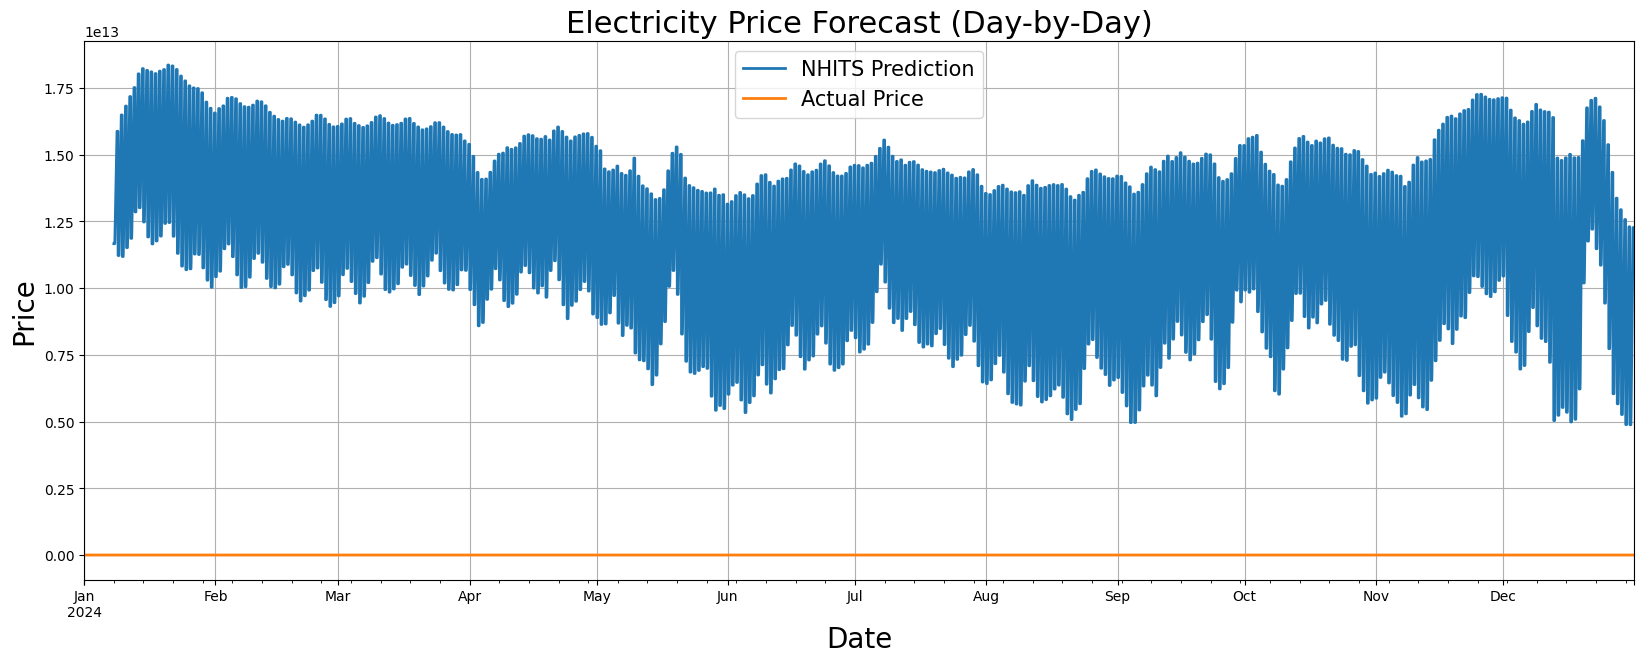

In [9]:
import matplotlib.pyplot as plt

# Plotting
fig, ax = plt.subplots(1, 1, figsize=(20, 7))

# Plot predictions for model
forecast_df.set_index('ds')['y_pred'].plot(ax=ax, linewidth=2, label= f'{model_name} Prediction')

# Optional: Plot actual test values for comparison
test_df.set_index('ds')['y'].plot(ax=ax, linewidth=2, label='Actual Price')

# Formatting the plot
ax.set_title('Electricity Price Forecast (Day-by-Day)', fontsize=22)
ax.set_ylabel('Price', fontsize=20)
ax.set_xlabel('Date', fontsize=20)
ax.legend(prop={'size': 15})
ax.grid()
plt.show()

In [10]:
forecast_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8616 entries, 0 to 8615
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype                        
---  ------    --------------  -----                        
 0   ds        8616 non-null   datetime64[ns, Europe/Berlin]
 1   y_pred    8616 non-null   float32                      
 2   y_actual  8616 non-null   float64                      
dtypes: datetime64[ns, Europe/Berlin](1), float32(1), float64(1)
memory usage: 168.4 KB


In [11]:
forecast_df.head()

,ds,y_pred,y_actual
0,2024-01-08 00:00:00+01:00,1.166117e+13,87.02
1,2024-01-08 01:00:00+01:00,1.166117e+13,84.32
2,2024-01-08 02:00:00+01:00,1.166117e+13,81.82
3,2024-01-08 03:00:00+01:00,1.166117e+13,79.11
4,2024-01-08 04:00:00+01:00,1.166117e+13,78.48


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Calculate error metrics
mae = mean_absolute_error(forecast_df['y_actual'], forecast_df['y_pred'])
mse = mean_squared_error(forecast_df['y_actual'], forecast_df['y_pred'])
rmse = np.sqrt(mse)

# Print the results
print("Model Performance:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")

Model Performance:
Mean Absolute Error (MAE): 11820301757780.55
Mean Squared Error (MSE): 149752265277912847042478080.00
Root Mean Squared Error (RMSE): 12237330806916.71


In [13]:
# Merge forecasted values with actual test data, selecting only the relevant columns
comparison_df = forecast_df[['ds', 'y_pred']].merge(test_df[['ds', 'y']], on='ds', how='inner')
comparison_df.rename(columns={'y': 'y_actual', 'y_pred': 'y_pred'}, inplace=True)

# Add a column for the day of the week (0=Monday, 1=Tuesday, ..., 6=Sunday)
comparison_df['day_of_week'] = comparison_df['ds'].dt.dayofweek

# Calculate and display MAE, MSE, and RMSE for each day of the week
metrics_by_day = {}

for day in range(7):
    # Filter data for each day of the week
    day_data = comparison_df[comparison_df['day_of_week'] == day]

    # Calculate the metrics for this day
    mae = mean_absolute_error(day_data['y_actual'], day_data['y_pred'])
    mse = mean_squared_error(day_data['y_actual'], day_data['y_pred'])
    rmse = np.sqrt(mse)

    # Store the metrics for each day
    metrics_by_day[day] = {
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse
    }

# Optionally, you can store these results in a DataFrame for easy viewing or further analysis
metrics_df = pd.DataFrame(metrics_by_day).T
print("\nMetrics by Day of the Week:")
print(metrics_df)


Metrics by Day of the Week:
            MAE           MSE          RMSE
0  1.200897e+13  1.537194e+26  1.239836e+13
1  1.161229e+13  1.454106e+26  1.205863e+13
2  1.150171e+13  1.429676e+26  1.195691e+13
3  1.158086e+13  1.444739e+26  1.201973e+13
4  1.165981e+13  1.462572e+26  1.209369e+13
5  1.208484e+13  1.554215e+26  1.246682e+13
6  1.229400e+13  1.600230e+26  1.265002e+13


/scratch/slurm_tmpdir/job_25287200/ipykernel_365176/644738538.py:9: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  unique_months = forecast_df['ds'].dt.to_period('M').unique()
/scratch/slurm_tmpdir/job_25287200/ipykernel_365176/644738538.py:20: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  forecast_month = forecast_df[forecast_df['ds'].dt.to_period('M') == month]
/scratch/slurm_tmpdir/job_25287200/ipykernel_365176/644738538.py:21: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  test_month = test_df[test_df['ds'].dt.to_period('M') == month]


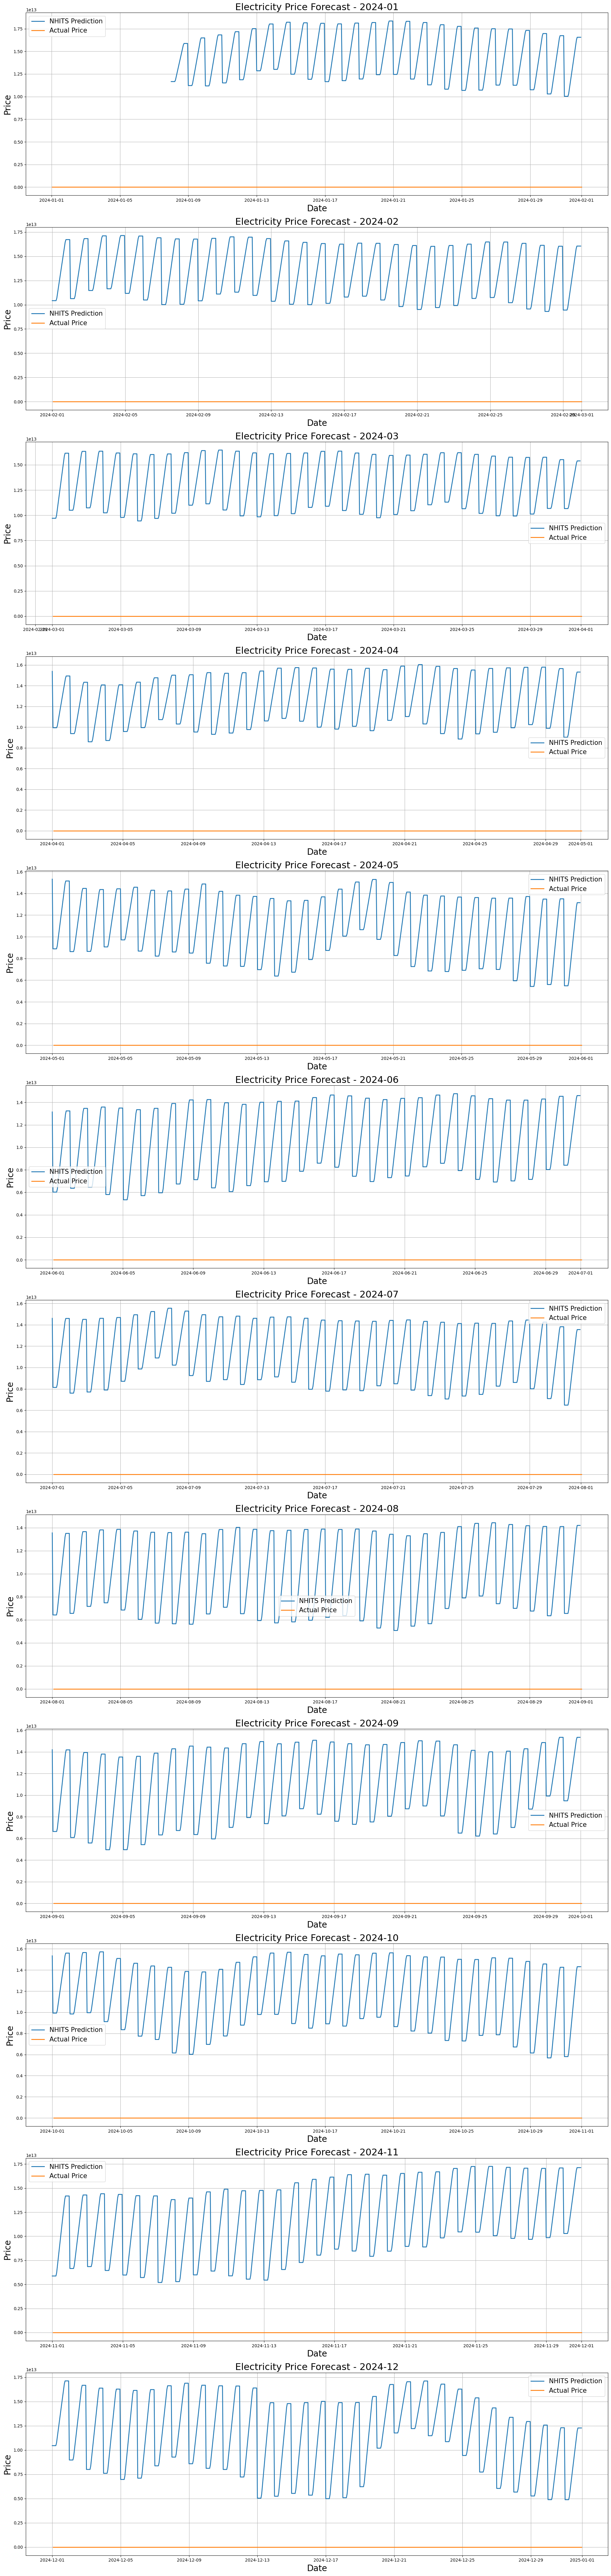

In [14]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'ds' is in datetime format
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])
test_df['ds'] = pd.to_datetime(test_df['ds'])

# Create a new figure with multiple subplots, one for each month
unique_months = forecast_df['ds'].dt.to_period('M').unique()

# Set up the figure and axes for plotting
fig, axes = plt.subplots(len(unique_months), 1, figsize=(20, 7 * len(unique_months)))

if len(unique_months) == 1:
    axes = [axes]  # Ensure axes is iterable even if there's only one subplot

for i, month in enumerate(unique_months):
    # Create the data subset for the current month
    month_str = str(month)
    forecast_month = forecast_df[forecast_df['ds'].dt.to_period('M') == month]
    test_month = test_df[test_df['ds'].dt.to_period('M') == month]

    # Plot predictions for the current month
    axes[i].plot(forecast_month['ds'], forecast_month['y_pred'], linewidth=2, label=f'{model_name} Prediction')

    # Plot actual test values for comparison in the current month
    axes[i].plot(test_month['ds'], test_month['y'], linewidth=2, label='Actual Price')

    # Formatting the plot for the current month
    axes[i].set_title(f'Electricity Price Forecast - {month_str}', fontsize=22)
    axes[i].set_ylabel('Price', fontsize=20)
    axes[i].set_xlabel('Date', fontsize=20)
    axes[i].legend(prop={'size': 15})
    axes[i].grid()

# Show the plot
plt.tight_layout()
plt.show()

In [15]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure 'ds' is in datetime format
forecast_df['ds'] = pd.to_datetime(forecast_df['ds'])
test_df['ds'] = pd.to_datetime(test_df['ds'])

# Create a new figure with multiple subplots, one for each biweekly period
# Group the data by biweekly periods
forecast_df['biweek'] = forecast_df['ds'].dt.to_period('2W')
test_df['biweek'] = test_df['ds'].dt.to_period('2W')

# Get the unique biweekly periods
unique_biweeks = forecast_df['biweek'].unique()

# Set up the figure and axes for plotting
fig, axes = plt.subplots(len(unique_biweeks), 1, figsize=(20, 7 * len(unique_biweeks)))

if len(unique_biweeks) == 1:
    axes = [axes]  # Ensure axes is iterable even if there's only one subplot

for i, biweek in enumerate(unique_biweeks):
    # Create the data subset for the current biweekly period
    biweek_str = str(biweek)
    forecast_biweek = forecast_df[forecast_df['biweek'] == biweek]
    test_biweek = test_df[test_df['biweek'] == biweek]

    # Plot predictions for the current biweekly period
    axes[i].plot(forecast_biweek['ds'], forecast_biweek['y_pred'], linewidth=2, label=f'{model_name} Prediction')

    # Plot actual test values for comparison in the current biweekly period
    axes[i].plot(test_biweek['ds'], test_biweek['y'], linewidth=2, label='Actual Price')

    # Formatting the plot for the current biweekly period
    axes[i].set_title(f'Electricity Price Forecast - {biweek_str}', fontsize=22)
    axes[i].set_ylabel('Price', fontsize=20)
    axes[i].set_xlabel('Date', fontsize=20)
    axes[i].legend(prop={'size': 15})
    axes[i].grid()

# Show the plot
plt.tight_layout()
plt.show()

/scratch/slurm_tmpdir/job_25287200/ipykernel_365176/1878128762.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  forecast_df['biweek'] = forecast_df['ds'].dt.to_period('2W')
/scratch/slurm_tmpdir/job_25287200/ipykernel_365176/1878128762.py:11: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  test_df['biweek'] = test_df['ds'].dt.to_period('2W')
